This exercise demonstrates basic DICOM handling using Python and pydicom, including image visualization and extraction of key identifiers across the Patient–Study–Series–Instance hierarchy.

In [13]:
#Import library for DICOM files managment
import pydicom    

# Call a test DICOM file that is included in the library (anonymized studies)
from pydicom.data import get_testdata_file  
filename = get_testdata_file("CT_small.dcm")
ds = pydicom.dcmread(filename)

# Takes binary data nto an image matrix
dsm = ds.pixel_array

# Prints the dimension of the image in px
print("Image dimensions:", dsm.shape)

Image dimensions: (128, 128)


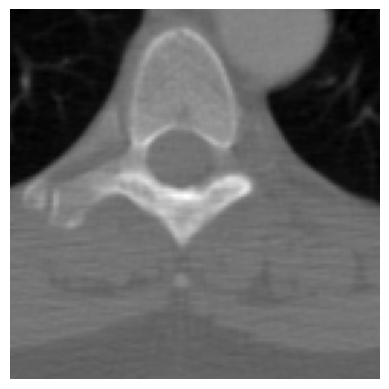

In [14]:
# To see the image  = print the matrix.
import matplotlib.pyplot as plt
plt.imshow(dsm , cmap='gray')
plt.axis('off') # matrix without axis
plt.show()

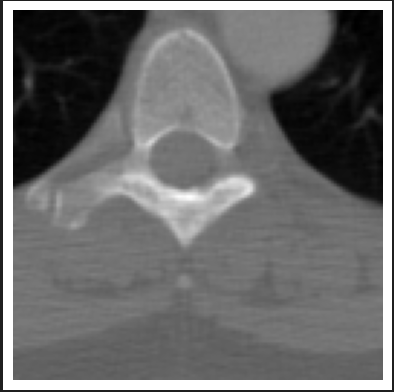

In [15]:
# Metadata overview
# Note: "getattr" avoids error if tag does not exist.

print("\n--- HIERARCHY IDENTIFIERS ---")
print("Patient ID:", ds.PatientID)
print("Study Instance UID:", ds.StudyInstanceUID)
print("Series Instance UID:", ds.SeriesInstanceUID)
print("SOP Instance UID:", ds.SOPInstanceUID)

# --- BASIC METADATA ---
print("\n--- BASIC METADATA ---")
print("Patient Name:", ds.PatientName)
print("Modality:", ds.Modality)
print("Study Date:", ds.StudyDate)
print("Body Part:", getattr(ds, "BodyPartExamined", "N/A"))

# --- SOP CLASS ---
print("\n--- SOP CLASS ---")
print("SOP Class UID:", ds.SOPClassUID)

# --- DATASET STRUCTURE ---
print("\n--- DATASET OVERVIEW ---")
print(ds[:])  # Metadata only (without pixel data)


--- HIERARCHY IDENTIFIERS ---
Patient ID: 1CT1
Study Instance UID: 1.3.6.1.4.1.5962.1.2.1.20040119072730.12322
Series Instance UID: 1.3.6.1.4.1.5962.1.3.1.1.20040119072730.12322
SOP Instance UID: 1.3.6.1.4.1.5962.1.1.1.1.1.20040119072730.12322

--- BASIC METADATA ---
Patient Name: CompressedSamples^CT1
Modality: CT
Study Date: 20040119
Body Part: N/A

--- SOP CLASS ---
SOP Class UID: 1.2.840.10008.5.1.4.1.1.2

--- DATASET OVERVIEW ---
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0012) Instance Creation Date              DA: '20040119'
(0008,0013) Instance Creation Time              TM: '072731'
(0008,0014) Instance Creator UID                UI: 1.3.6.1.4.1.5962.3
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.5962.1.1.1.1.1.20040119072730.12322
(0008,0020) Study Date                        

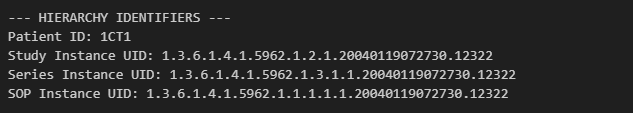

* Study Instance UID identifies the imaging study
* Series Instance UID identifies a specific acquisition within that study
* SOP Instance UID uniquely identifies each individual image globally across all DICOM systems (not just a particular PACS system).

1.3.6.1.4.1 = root assigned to an organization
5962        = manufacturer or software
...          = study / series / instance 
20040119072730 = date and time
12322            = aditional number 

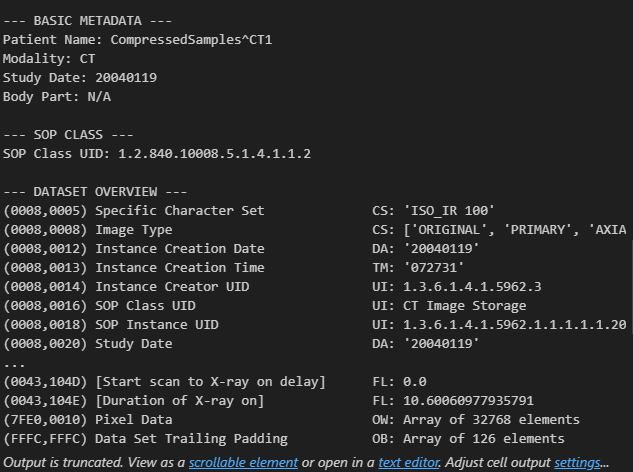